# DSCI 552 Homework 2

**Name:** Hao Pang  
**USC ID:** 6495868529

## 1. Combined Cycle Power Plant Data Set

### 1(a) Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_excel("Folds5x2_pp.xlsx", sheet_name="Sheet1")

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9568
Number of columns: 5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

I loaded the data from Sheet1 of the Excel file. It has 9,568 observations and 5 variables. AT, V, AP and RH are the predictors, and PE is the response. There are no missing values.

### 1(b) Exploring the Data

#### 1(b)(i) Number of Rows and Columns

The data set has 9,568 rows and 5 columns. Each row is one hourly average record from the power plant when it was running at full load (collected from 2006 to 2011). Each column is one variable:

- **AT:** Ambient Temperature (°C)
- **V:** Exhaust Vacuum (cm Hg)
- **AP:** Ambient Pressure (millibar)
- **RH:** Relative Humidity (%)
- **PE:** Net hourly electrical energy output (MW), this is the response

#### 1(b)(ii) Scatterplot Matrix

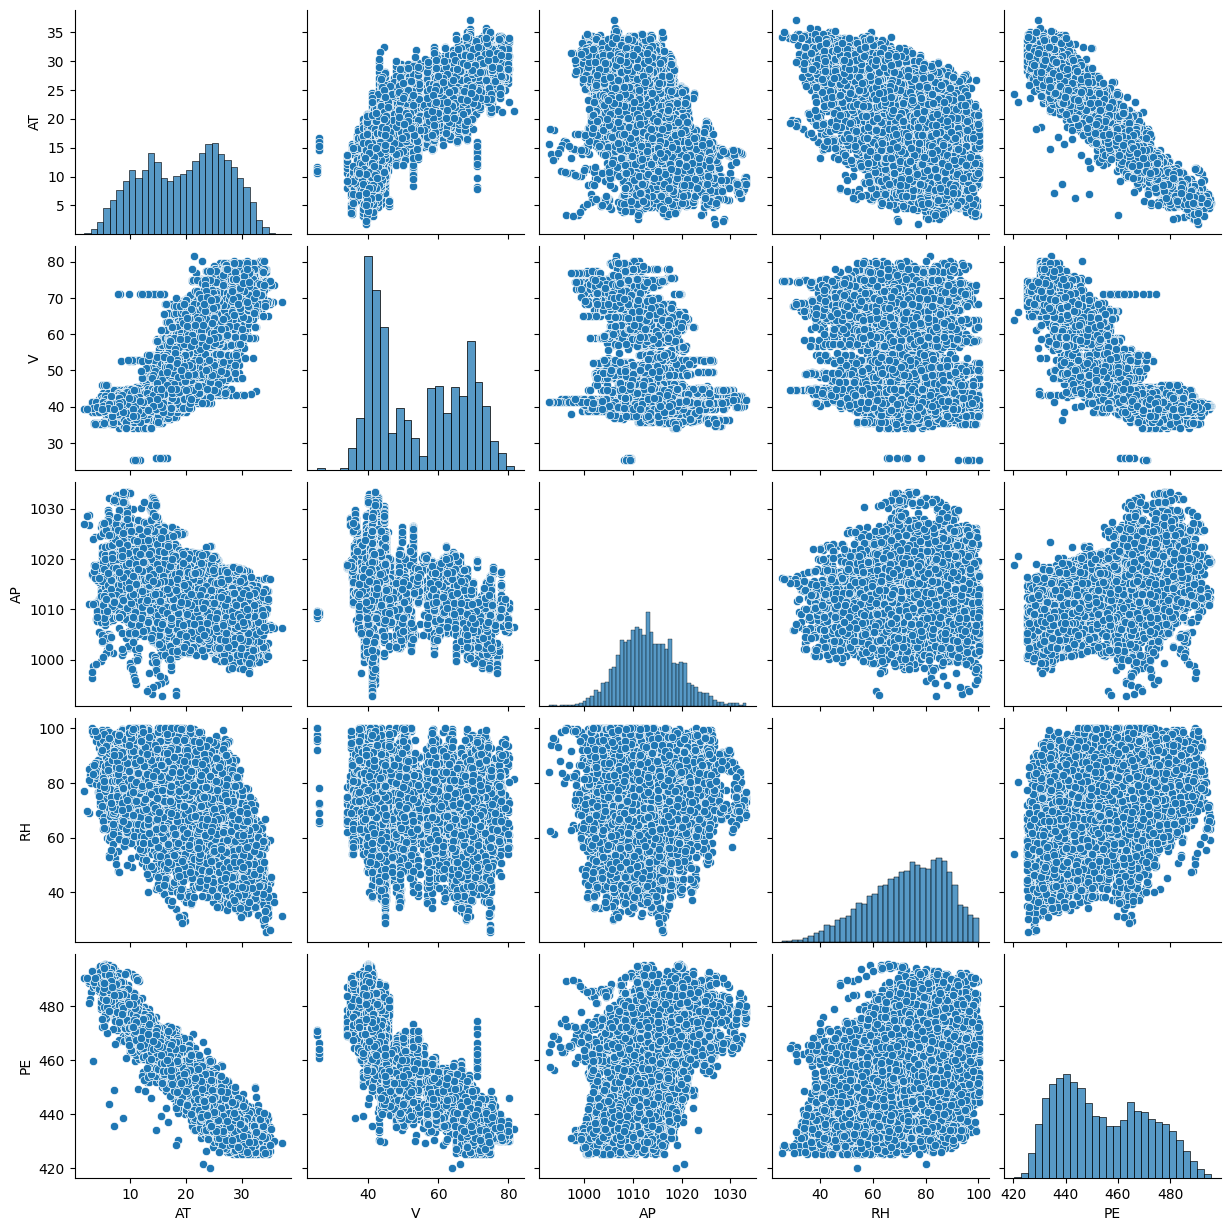

In [6]:
sns.pairplot(df, diag_kind="hist")
plt.show()

From the pairplot, PE has a strong negative relationship with AT. When the temperature goes up, the power output goes down, and the points are close to a straight line. PE also goes down when V increases, but the points are more spread out and the pattern is not as linear. AP has a weak positive relationship with PE, and RH has an even weaker positive relationship with PE.

Some predictors are also related to each other. AT and V are positively related, and AT and AP are negatively related. So there may be some collinearity between the predictors. Some plots look a little curved, so nonlinear terms may help later. I can also see a few points that are far from the others, which could be outliers.

#### 1(b)(iii) Summary Statistics

In [7]:
summary_statistics = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Minimum": df.min(),
    "Maximum": df.max(),
    "Range": df.max() - df.min(),
    "First Quartile": df.quantile(0.25),
    "Third Quartile": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary_statistics.round(2)

,Mean,Median,Minimum,Maximum,Range,First Quartile,Third Quartile,IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


For every variable, the mean and the median are quite close, so the distributions are not very skewed. PE has a mean of 454.37 MW and a median of 451.55 MW. It goes from 420.26 MW to 495.76 MW, and its IQR is 28.68 MW. The predictors have very different units and ranges (for example, AP is around 1000 but AT is around 20), so I need to scale the features before using KNN later.

### 1(c) Simple Linear Regression

#### PE and AT

In [8]:
model_AT = smf.ols("PE ~ AT", data=df).fit()

print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:59:38   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.0

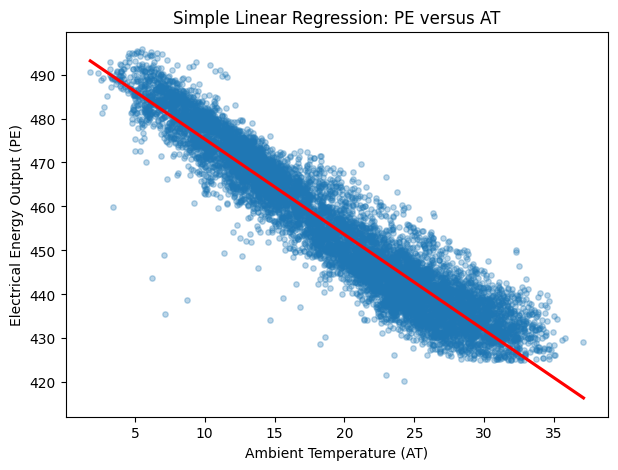

In [9]:
plt.figure(figsize=(7, 5))

sns.regplot(
    data=df,
    x="AT",
    y="PE",
    scatter_kws={"alpha": 0.3, "s": 15},
    line_kws={"color": "red"}
)

plt.title("Simple Linear Regression: PE versus AT")
plt.xlabel("Ambient Temperature (AT)")
plt.ylabel("Electrical Energy Output (PE)")
plt.show()

There is a strong negative relationship between AT and PE. The fitted line is:

$$
\widehat{PE} = 497.0341 - 2.1713(AT)
$$

When AT goes up by 1 °C, PE goes down by about 2.17 MW on average. The p-value of AT is less than 0.001, so AT is significant. The R-squared is 0.899, which means AT alone explains about 89.9% of the variation in PE. In the plot, most points are close to the red line, but there are a few points far from it.

#### PE and V

In [10]:
model_V = smf.ols("PE ~ V", data=df).fit()

print(model_V.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:59:38   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    517.8015      0.378   1370.218      0.0

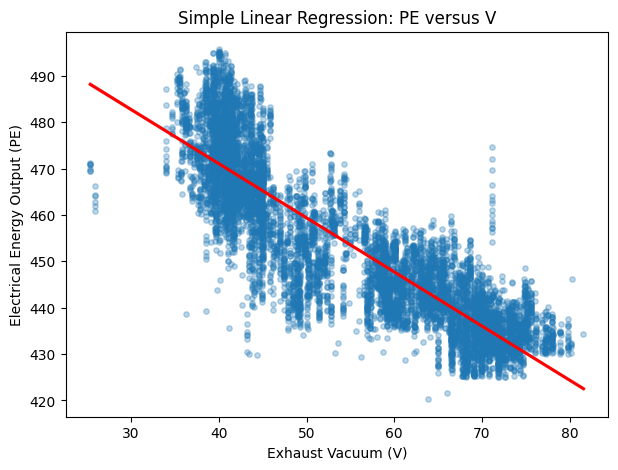

In [11]:
plt.figure(figsize=(7, 5))

sns.regplot(
    data=df,
    x="V",
    y="PE",
    scatter_kws={"alpha": 0.3, "s": 15},
    line_kws={"color": "red"}
)

plt.title("Simple Linear Regression: PE versus V")
plt.xlabel("Exhaust Vacuum (V)")
plt.ylabel("Electrical Energy Output (PE)")
plt.show()

There is a negative relationship between V and PE. The fitted line is:

$$
\widehat{PE} = 517.8015 - 1.1681(V)
$$

When V goes up by 1 cm Hg, PE goes down by about 1.17 MW on average. The p-value is less than 0.001, so V is significant. The R-squared is 0.757, so V alone explains about 75.7% of the variation in PE. From the plot, the points are more spread out than in the AT plot, and the relationship does not look perfectly linear.

#### PE and AP

In [12]:
model_AP = smf.ols("PE ~ AP", data=df).fit()

print(model_AP.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:59:39   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1055.2610     25.459    -41.449      0.0

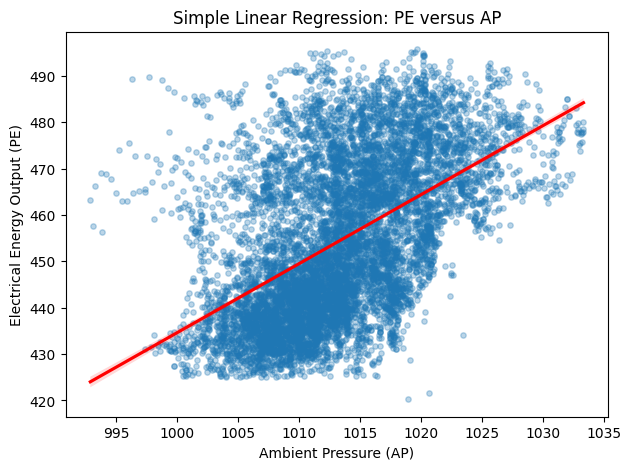

In [13]:
plt.figure(figsize=(7, 5))

sns.regplot(
    data=df,
    x="AP",
    y="PE",
    scatter_kws={"alpha": 0.3, "s": 15},
    line_kws={"color": "red"}
)

plt.title("Simple Linear Regression: PE versus AP")
plt.xlabel("Ambient Pressure (AP)")
plt.ylabel("Electrical Energy Output (PE)")
plt.show()

There is a positive relationship between AP and PE. The fitted line is:

$$
\widehat{PE} = -1055.2610 + 1.4899(AP)
$$

When AP goes up by 1 millibar, PE goes up by about 1.49 MW on average. The p-value is less than 0.001, so AP is significant. But the R-squared is only 0.269, so AP alone only explains about 26.9% of the variation in PE. In the plot, the trend is positive but the points are very spread out around the line.

#### PE and RH

In [14]:
model_RH = smf.ols("PE ~ RH", data=df).fit()

print(model_RH.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:59:39   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    420.9618      0.823    511.676      0.0

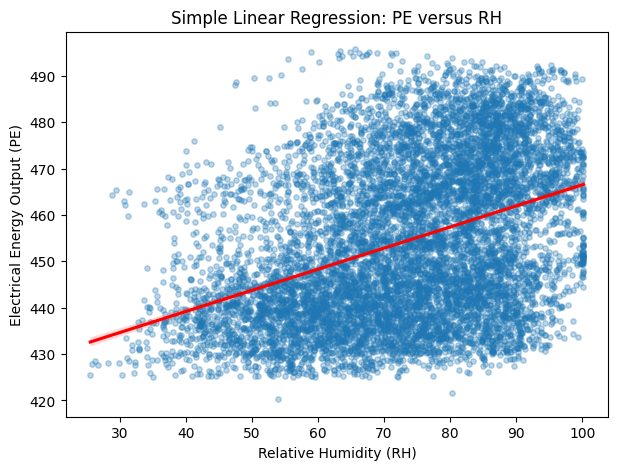

In [15]:
plt.figure(figsize=(7, 5))

sns.regplot(
    data=df,
    x="RH",
    y="PE",
    scatter_kws={"alpha": 0.3, "s": 15},
    line_kws={"color": "red"}
)

plt.title("Simple Linear Regression: PE versus RH")
plt.xlabel("Relative Humidity (RH)")
plt.ylabel("Electrical Energy Output (PE)")
plt.show()

There is a positive relationship between RH and PE. The fitted line is:

$$
\widehat{PE} = 420.9618 + 0.4557(RH)
$$

When RH goes up by 1 percentage point, PE goes up by about 0.46 MW on average. The p-value is less than 0.001, so RH is also significant. However, the R-squared is only 0.152, so RH alone does not predict PE very well. The points are widely spread around the line.

In [16]:
simple_regression_results = pd.DataFrame({
    "Predictor": ["AT", "V", "AP", "RH"],
    "Coefficient": [
        model_AT.params["AT"],
        model_V.params["V"],
        model_AP.params["AP"],
        model_RH.params["RH"]
    ],
    "P-value": [
        model_AT.pvalues["AT"],
        model_V.pvalues["V"],
        model_AP.pvalues["AP"],
        model_RH.pvalues["RH"]
    ],
    "R-squared": [
        model_AT.rsquared,
        model_V.rsquared,
        model_AP.rsquared,
        model_RH.rsquared
    ]
})

simple_regression_results.round(4)

,Predictor,Coefficient,P-value,R-squared
0,AT,-2.1713,0.0,0.8989
1,V,-1.1681,0.0,0.7565
2,AP,1.4899,0.0,0.2688
3,RH,0.4557,0.0,0.1519



#### Outliers and High Leverage Points

To check for outliers in each simple regression, I computed the studentized residuals, leverage and Cook's distance. I treat a point as an outlier if its |studentized residual| > 3, and as a high leverage point if its leverage > 3(p+1)/n. For Cook's distance, a value larger than 1 usually means the point is very influential. I also refit each model without the outliers to see how much the results change.


In [17]:
n = len(df)
simple_models = {"AT": model_AT, "V": model_V, "AP": model_AP, "RH": model_RH}

outlier_results = []
outlier_masks = {}

for predictor, model in simple_models.items():
    influence = model.get_influence()
    stud_resid = influence.resid_studentized_external
    leverage = influence.hat_matrix_diag
    cooks_d = influence.cooks_distance[0]

    is_outlier = np.abs(stud_resid) > 3
    high_leverage = leverage > 3 * 2 / n
    outlier_masks[predictor] = is_outlier

    model_no_outlier = smf.ols(f"PE ~ {predictor}", data=df[~is_outlier]).fit()

    outlier_results.append({
        "Predictor": predictor,
        "Outliers (|r| > 3)": is_outlier.sum(),
        "High Leverage": high_leverage.sum(),
        "Both": (is_outlier & high_leverage).sum(),
        "Max Cook's D": cooks_d.max(),
        "Coef (all data)": model.params[predictor],
        "Coef (no outliers)": model_no_outlier.params[predictor],
        "R2 (all data)": model.rsquared,
        "R2 (no outliers)": model_no_outlier.rsquared
    })

outlier_results = pd.DataFrame(outlier_results)
outlier_results.round(4)

,Predictor,Outliers (|r| > 3),High Leverage,Both,Max Cook's D,Coef (all data),Coef (no outliers),R2 (all data),R2 (no outliers)
0,AT,42,7,0,0.0143,-2.1713,-2.1802,0.8989,0.9064
1,V,33,13,2,0.0032,-1.1681,-1.1769,0.7565,0.7670
2,AP,30,239,9,0.0082,1.4899,1.5401,0.2688,0.2864
3,RH,2,173,0,0.0021,0.4557,0.4564,0.1519,0.1526


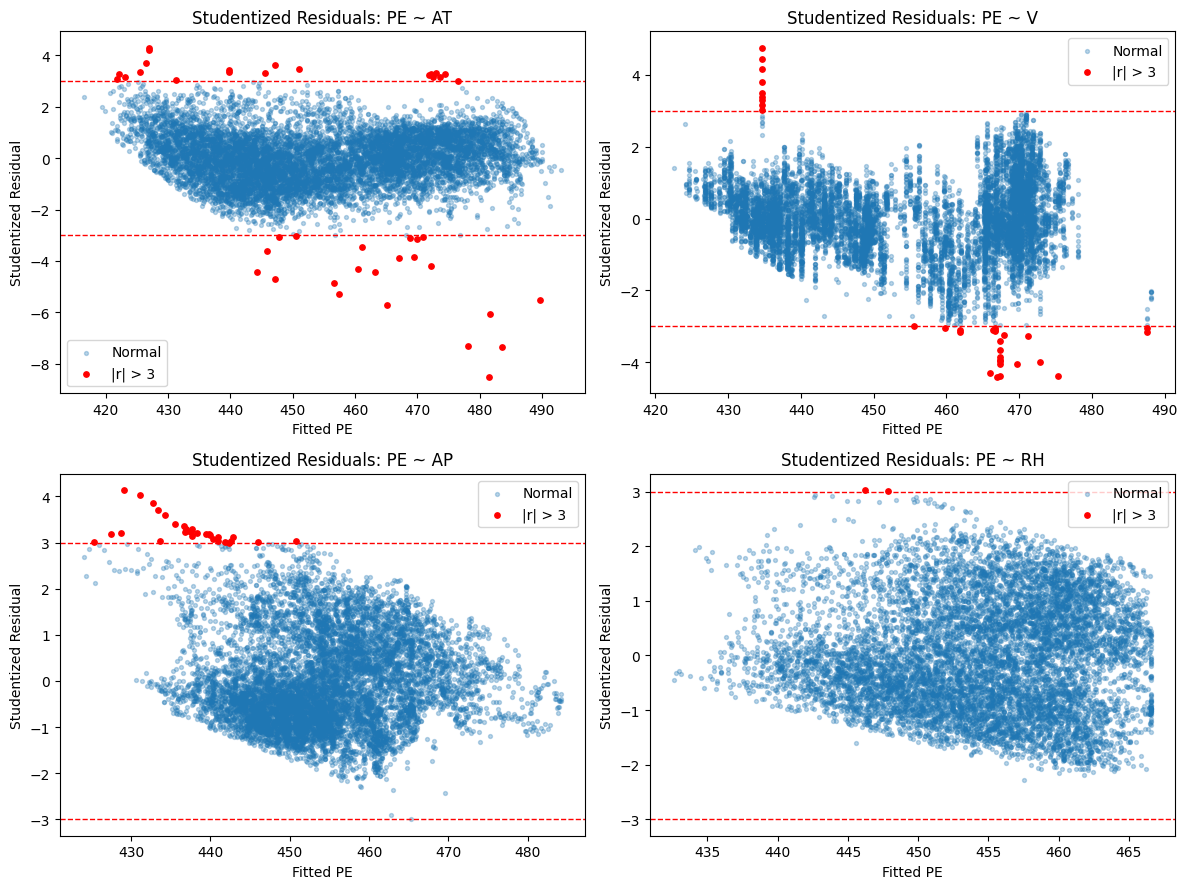

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (predictor, model) in zip(axes.flat, simple_models.items()):
    influence = model.get_influence()
    stud_resid = influence.resid_studentized_external
    mask = outlier_masks[predictor]

    ax.scatter(model.fittedvalues[~mask], stud_resid[~mask], s=8, alpha=0.3, label="Normal")
    ax.scatter(model.fittedvalues[mask], stud_resid[mask], s=15, color="red", label="|r| > 3")
    ax.axhline(3, color="red", linestyle="--", linewidth=1)
    ax.axhline(-3, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Studentized Residuals: PE ~ {predictor}")
    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Studentized Residual")
    ax.legend()

plt.tight_layout()
plt.show()


Each simple regression has some outliers: 42 for AT, 33 for V, 30 for AP and only 2 for RH. This is less than 0.5% of the 9,568 observations. The largest Cook's distance for all four models is less than 0.02, which is far below 1, so no single point has a big influence on the fitted line. Only a few points (2 for V and 9 for AP) are both outliers and high leverage points.

When I remove the outliers and refit, the coefficients barely change (for example, AT goes from -2.1713 to -2.1802), and R-squared only improves a little. Also, these points look like real measurements from the power plant, not data entry errors. So I decided **not to remove** them. Keeping them gives a more honest picture of the data, and removing them would not change the conclusions.


All four predictors have a statistically significant association with PE, because all p-values are less than 0.001. This is not very surprising because the sample size is large (9,568), so even a weak relationship can be significant. AT and V have negative coefficients, and AP and RH have positive coefficients. Based on R-squared, AT is the best single predictor, then V, AP and RH.

### 1(d) Multiple Linear Regression

In [19]:
multiple_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=df
).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:01:25   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

The multiple regression model has an R-squared of 0.929 (adjusted R-squared is also 0.929). So the four predictors together explain about 92.9% of the variation in PE, which is better than any single-predictor model.

The fitted model is:

$$
\widehat{PE}
= 454.6093
- 1.9775(AT)
- 0.2339(V)
+ 0.0621(AP)
- 0.1581(RH)
$$

All four p-values are less than 0.001, so we can reject $H_0: \beta_j = 0$ for AT, V, AP and RH. Each predictor is still significant after controlling for the other predictors.

When the other variables are fixed, AT, V and RH have negative effects on PE, and AP has a positive effect. One interesting thing is that the sign of RH changed from positive (in the simple regression) to negative here. I think this is because RH is correlated with the other predictors, especially AT, so in the simple regression part of the AT effect was picked up by RH.

### 1(e) Comparison of Regression Coefficients

In [20]:
coefficient_comparison = pd.DataFrame({
    "Predictor": ["AT", "V", "AP", "RH"],
    "Simple Regression": [
        model_AT.params["AT"],
        model_V.params["V"],
        model_AP.params["AP"],
        model_RH.params["RH"]
    ],
    "Multiple Regression": [
        multiple_model.params["AT"],
        multiple_model.params["V"],
        multiple_model.params["AP"],
        multiple_model.params["RH"]
    ]
})

coefficient_comparison.round(4)

,Predictor,Simple Regression,Multiple Regression
0,AT,-2.1713,-1.9775
1,V,-1.1681,-0.2339
2,AP,1.4899,0.0621
3,RH,0.4557,-0.1581


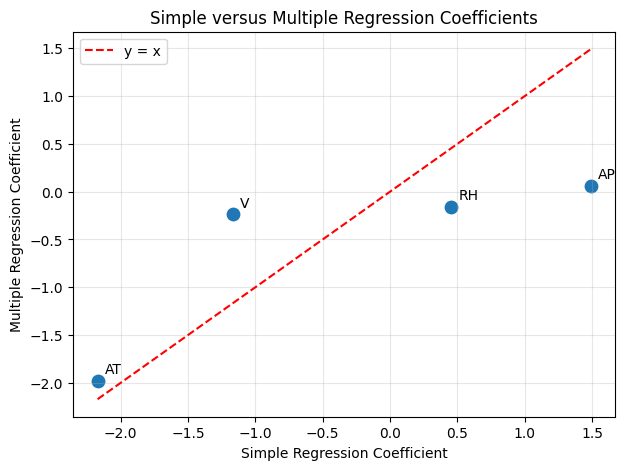

In [21]:
plt.figure(figsize=(7, 5))

plt.scatter(
    coefficient_comparison["Simple Regression"],
    coefficient_comparison["Multiple Regression"],
    s=80
)

for _, row in coefficient_comparison.iterrows():
    plt.annotate(
        row["Predictor"],
        (row["Simple Regression"], row["Multiple Regression"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

all_coefficients = pd.concat([
    coefficient_comparison["Simple Regression"],
    coefficient_comparison["Multiple Regression"]
])

line_min = all_coefficients.min()
line_max = all_coefficients.max()

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    color="red",
    linestyle="--",
    label="y = x"
)

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple versus Multiple Regression Coefficients")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The coefficients are different between the two kinds of models. AT changes only a little (from -2.17 to -1.98), so it is close to the y = x line. The coefficients of V and AP become much smaller in the multiple regression, and RH changes from positive to negative.

The reason is that a simple regression only looks at one predictor, so its coefficient also includes the effects of other predictors that are correlated with it. In the multiple regression, each coefficient is the effect of that predictor while holding the others fixed. Because the predictors are correlated (for example, AT and V), the size and even the sign of a coefficient can change.

### 1(f) Nonlinear Relationships

In [22]:
predictors = ["AT", "V", "AP", "RH"]

polynomial_models = {}
nonlinear_results = []

for predictor in predictors:
    polynomial_data = pd.DataFrame({
        "PE": df["PE"],
        "X": df[predictor] - df[predictor].mean()
    })
    
    model = smf.ols(
        "PE ~ X + I(X ** 2) + I(X ** 3)",
        data=polynomial_data
    ).fit()
    
    polynomial_models[predictor] = model
    
    nonlinear_results.append({
        "Predictor": predictor,
        "Linear P-value": model.pvalues["X"],
        "Squared P-value": model.pvalues["I(X ** 2)"],
        "Cubic P-value": model.pvalues["I(X ** 3)"],
        "R-squared": model.rsquared
    })

nonlinear_results = pd.DataFrame(nonlinear_results)

nonlinear_results

,Predictor,Linear P-value,Squared P-value,Cubic P-value,R-squared
0,AT,0.000000e+00,3.311808e-231,3.652185e-110,0.911883
1,V,0.000000e+00,8.977010e-131,1.373489e-02,0.775022
2,AP,0.000000e+00,2.192722e-46,2.123338e-67,0.297543
3,RH,9.648727e-152,1.013949e-01,1.440279e-05,0.153743


In [23]:
nonlinear_test_results = []

for predictor in predictors:
    polynomial_data = pd.DataFrame({
        "PE": df["PE"],
        "X": df[predictor] - df[predictor].mean()
    })
    
    linear_model = smf.ols(
        "PE ~ X",
        data=polynomial_data
    ).fit()
    
    cubic_model = polynomial_models[predictor]
    
    f_statistic, p_value, df_difference = (
        cubic_model.compare_f_test(linear_model)
    )
    
    nonlinear_test_results.append({
        "Predictor": predictor,
        "F-statistic": f_statistic,
        "Nonlinearity P-value": p_value
    })

nonlinear_test_results = pd.DataFrame(nonlinear_test_results)

nonlinear_test_results

,Predictor,F-statistic,Nonlinearity P-value
0,AT,701.967278,3.478379e-285
1,V,393.314147,7.040304e-165
2,AP,195.885627,4.209145e-84
3,RH,10.188863,3.799622e-05


I used an F-test to compare each cubic model with the simple linear model. The p-values for AT, V, AP and RH are all less than 0.05, so there is evidence of a nonlinear relationship between each predictor and PE.

Looking at the single terms:
- **AT:** both the squared term and the cubic term are significant.
- **V:** both higher-order terms are significant (the cubic term p-value is about 0.014, so it is significant at the 0.05 level but much weaker).
- **AP:** both the squared term and the cubic term are significant.
- **RH:** the squared term is not significant (p ≈ 0.10), but the cubic term is significant.

So adding nonlinear terms improves the model for all four predictors. The improvement for RH is very small though (R-squared only goes from 0.152 to 0.154), while AT, V and AP improve more.

### 1(g) Interaction Effects

In [24]:
interaction_model = smf.ols(
    "PE ~ (AT + V + AP + RH) ** 2",
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:01:26   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [25]:
interaction_terms = [
    "AT:V",
    "AT:AP",
    "AT:RH",
    "V:AP",
    "V:RH",
    "AP:RH"
]

interaction_results = pd.DataFrame({
    "Interaction": interaction_terms,
    "Coefficient": [
        interaction_model.params[term]
        for term in interaction_terms
    ],
    "P-value": [
        interaction_model.pvalues[term]
        for term in interaction_terms
    ]
})

interaction_results

,Interaction,Coefficient,P-value
0,AT:V,0.020971,3.333358e-117
1,AT:AP,0.001759,4.520509e-01
2,AT:RH,-0.005230,1.216944e-10
3,V:AP,0.006812,2.877026e-07
4,V:RH,0.000839,8.619366e-02
5,AP:RH,-0.001612,3.360557e-02


The model with all pairwise interactions has an R-squared of 0.936. At the 0.05 level, four of the six interaction terms are significant: AT:V, AT:RH, V:AP and AP:RH. So there is evidence that the effect of some predictors on PE depends on the value of other predictors. AT:V is the strongest one.

AT:AP (p = 0.452) and V:RH (p = 0.086) are not significant at the 0.05 level.

### 1(h) Model Improvement and Mean Squared Error

#### Train-Test Split

In [26]:
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (6697, 5)
Test set shape: (2871, 5)


#### Basic Multiple Linear Regression Model

In [27]:
basic_train_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=train_df
).fit()

basic_train_predictions = basic_train_model.predict(train_df)
basic_test_predictions = basic_train_model.predict(test_df)

basic_train_mse = mean_squared_error(
    train_df["PE"],
    basic_train_predictions
)

basic_test_mse = mean_squared_error(
    test_df["PE"],
    basic_test_predictions
)

print("Basic model training MSE:", round(basic_train_mse, 4))
print("Basic model test MSE:", round(basic_test_mse, 4))

Basic model training MSE: 20.5808
Basic model test MSE: 21.2399


The basic multiple regression model has a training MSE of 20.5808 and a test MSE of 21.2399. The two numbers are close, so the model does not seem to overfit.

#### Full Model with Nonlinear and Interaction Terms

In [28]:
predictors = ["AT", "V", "AP", "RH"]

training_means = train_df[predictors].mean()

train_centered = train_df.copy()
test_centered = test_df.copy()

for predictor in predictors:
    train_centered[f"{predictor}_c"] = (
        train_df[predictor] - training_means[predictor]
    )
    
    test_centered[f"{predictor}_c"] = (
        test_df[predictor] - training_means[predictor]
    )

In [29]:
full_formula = """
PE ~ AT_c + V_c + AP_c + RH_c
+ I(AT_c ** 2) + I(V_c ** 2)
+ I(AP_c ** 2) + I(RH_c ** 2)
+ AT_c:V_c + AT_c:AP_c + AT_c:RH_c
+ V_c:AP_c + V_c:RH_c + AP_c:RH_c
"""

full_train_model = smf.ols(
    full_formula,
    data=train_centered
).fit()

print(full_train_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:01:26   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      453.2447      0.117   3866.133   

I fitted the full model (all main effects, all squared terms and all pairwise interactions) using only the training data. The terms with p-values greater than 0.05 are V², AT:AP, V:AP and V:RH, so I removed them in the reduced model. I kept all four main effects even if some of them might not be significant, because of the hierarchy principle (if an interaction or squared term stays in the model, its main effects should stay too).

In [30]:
full_train_mse = mean_squared_error(train_centered["PE"], full_train_model.predict(train_centered))
full_test_mse = mean_squared_error(test_centered["PE"], full_train_model.predict(test_centered))

print("Full model training MSE:", round(full_train_mse, 4))
print("Full model test MSE:", round(full_test_mse, 4))

Full model training MSE: 17.8878
Full model test MSE: 18.6473


#### Reduced Nonlinear and Interaction Model

In [31]:
reduced_formula = """
PE ~ AT_c + V_c + AP_c + RH_c
+ I(AT_c ** 2)
+ I(AP_c ** 2)
+ I(RH_c ** 2)
+ AT_c:V_c
+ AT_c:RH_c
+ AP_c:RH_c
"""

reduced_train_model = smf.ols(
    reduced_formula,
    data=train_centered
).fit()

print(reduced_train_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:01:26   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      453.2887      0.097   4668.962   

In [32]:
reduced_train_predictions = reduced_train_model.predict(
    train_centered
)

reduced_test_predictions = reduced_train_model.predict(
    test_centered
)

reduced_train_mse = mean_squared_error(
    train_centered["PE"],
    reduced_train_predictions
)

reduced_test_mse = mean_squared_error(
    test_centered["PE"],
    reduced_test_predictions
)

print(
    "Reduced model training MSE:",
    round(reduced_train_mse, 4)
)

print(
    "Reduced model test MSE:",
    round(reduced_test_mse, 4)
)

Reduced model training MSE: 17.9178
Reduced model test MSE: 18.6943


In [33]:
linear_model_comparison = pd.DataFrame({
    "Model": [
        "Basic Multiple Linear Regression",
        "Full Model (all quadratic + interaction terms)",
        "Reduced Nonlinear and Interaction Model"
    ],
    "Training MSE": [
        basic_train_mse,
        full_train_mse,
        reduced_train_mse
    ],
    "Test MSE": [
        basic_test_mse,
        full_test_mse,
        reduced_test_mse
    ]
})

linear_model_comparison.round(4)

,Model,Training MSE,Test MSE
0,Basic Multiple Linear Regression,20.5808,21.2399
1,Full Model (all quadratic + interaction terms),17.8878,18.6473
2,Reduced Nonlinear and Interaction Model,17.9178,18.6943


The reduced model has a training MSE of 17.9178 and a test MSE of 18.6943. Both are lower than the basic model (20.5808 and 21.2399). The test MSE drops by about 12%. The full model (before removing terms) has a test MSE of 18.6473, which is almost the same as the reduced model. This means removing the insignificant terms did not hurt the prediction, and the model is simpler. The training and test MSE are close, so there is no obvious overfitting. So yes, adding some nonlinear and interaction terms improves the linear regression model.

### 1(i) KNN Regression

In [34]:
X_train = train_df[["AT", "V", "AP", "RH"]]
X_test = test_df[["AT", "V", "AP", "RH"]]

y_train = train_df["PE"]
y_test = test_df["PE"]

k_values = list(range(1, 101))

In [35]:
raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(X_train, y_train)
    
    raw_train_predictions = knn_raw.predict(X_train)
    raw_test_predictions = knn_raw.predict(X_test)
    
    raw_train_mse.append(
        mean_squared_error(y_train, raw_train_predictions)
    )
    
    raw_test_mse.append(
        mean_squared_error(y_test, raw_test_predictions)
    )

best_raw_index = np.argmin(raw_test_mse)
best_raw_k = k_values[best_raw_index]
best_raw_test_mse = raw_test_mse[best_raw_index]

print("Best k for raw features:", best_raw_k)
print("Best raw-feature test MSE:", round(best_raw_test_mse, 4))

Best k for raw features: 5
Best raw-feature test MSE: 15.7268


In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_train_mse = []
scaled_test_mse = []

for k in k_values:
    knn_scaled = KNeighborsRegressor(n_neighbors=k)
    knn_scaled.fit(X_train_scaled, y_train)
    
    scaled_train_predictions = knn_scaled.predict(
        X_train_scaled
    )
    
    scaled_test_predictions = knn_scaled.predict(
        X_test_scaled
    )
    
    scaled_train_mse.append(
        mean_squared_error(y_train, scaled_train_predictions)
    )
    
    scaled_test_mse.append(
        mean_squared_error(y_test, scaled_test_predictions)
    )

best_scaled_index = np.argmin(scaled_test_mse)
best_scaled_k = k_values[best_scaled_index]
best_scaled_test_mse = scaled_test_mse[best_scaled_index]

print("Best k for scaled features:", best_scaled_k)
print(
    "Best scaled-feature test MSE:",
    round(best_scaled_test_mse, 4)
)

Best k for scaled features: 4
Best scaled-feature test MSE: 14.3057


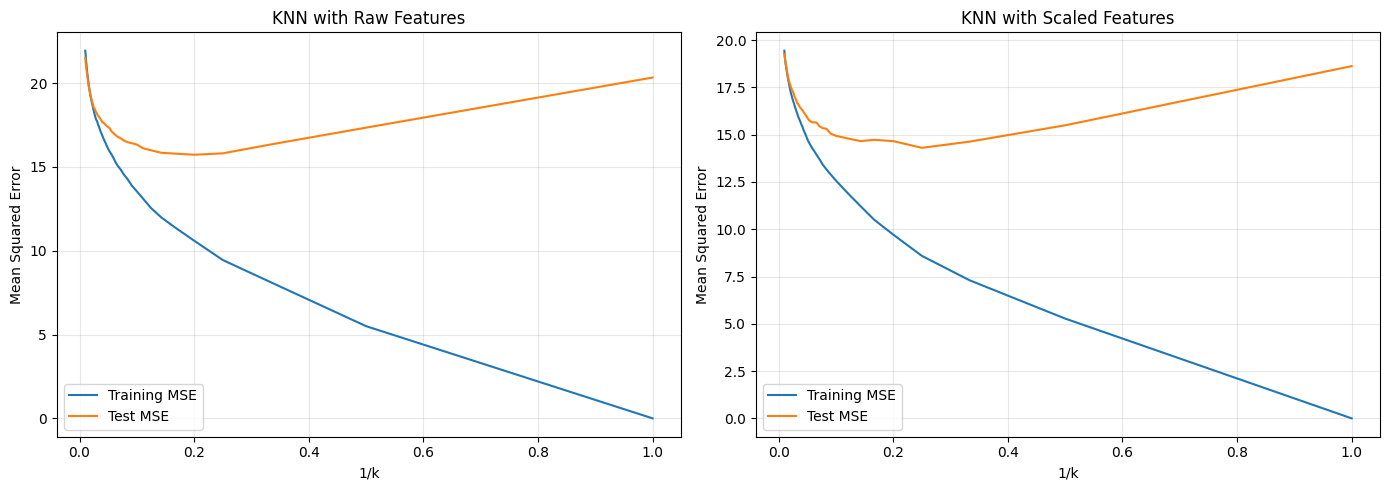

In [37]:
inverse_k = 1 / np.array(k_values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    inverse_k,
    raw_train_mse,
    label="Training MSE"
)

axes[0].plot(
    inverse_k,
    raw_test_mse,
    label="Test MSE"
)

axes[0].set_title("KNN with Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    inverse_k,
    scaled_train_mse,
    label="Training MSE"
)

axes[1].plot(
    inverse_k,
    scaled_test_mse,
    label="Test MSE"
)

axes[1].set_title("KNN with Scaled Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("Mean Squared Error")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

For raw features, the best k is 5, with a test MSE of 15.7268. For normalized features, the best k is 4, with a lower test MSE of 14.3057. (Here I used StandardScaler, so each feature has mean 0 and standard deviation 1. The scaler is fitted only on the training set.)

The normalized version works better because KNN uses distance. Without scaling, a variable with a bigger range (like V or RH) has a bigger effect on the distance than a variable with a small range, even if it is not more important. From the plots, when k = 1 (1/k = 1) the training MSE is 0 but the test MSE is higher, which is overfitting. As k increases (1/k becomes smaller), the test error first goes down and then slowly goes up again, because the model becomes too smooth.

In [38]:
best_raw_train_mse = raw_train_mse[best_raw_index]
best_scaled_train_mse = scaled_train_mse[best_scaled_index]

final_model_comparison = pd.DataFrame({
    "Model": [
        "Basic Multiple Linear Regression",
        "Reduced Nonlinear and Interaction Model",
        f"Raw KNN (k={best_raw_k})",
        f"Scaled KNN (k={best_scaled_k})"
    ],
    "Training MSE": [
        basic_train_mse,
        reduced_train_mse,
        best_raw_train_mse,
        best_scaled_train_mse
    ],
    "Test MSE": [
        basic_test_mse,
        reduced_test_mse,
        best_raw_test_mse,
        best_scaled_test_mse
    ]
})

final_model_comparison.round(4)

,Model,Training MSE,Test MSE
0,Basic Multiple Linear Regression,20.5808,21.2399
1,Reduced Nonlinear and Interaction Model,17.9178,18.6943
2,Raw KNN (k=5),10.6008,15.7268
3,Scaled KNN (k=4),8.5914,14.3057


### 1(j) Comparison of KNN and Linear Regression

Among the linear regression models, the full model with all quadratic and interaction terms has the smallest test MSE (18.6473), and the reduced model is almost the same (18.6943). But both KNN models have lower test MSE than these. The normalized KNN with k = 4 is the best overall, with a test MSE of 14.3057, which is about 23% lower than the best linear model.

I think this means the true relationship between the predictors and PE is more complex than what our selected regression terms can capture, and KNN, as a more flexible nonparametric method, can fit it better. Also, we have a lot of data (about 6,700 training points) and only 4 predictors, which is a good situation for KNN.

On the other hand, KNN has no coefficients, so it is hard to explain how each variable affects PE. Linear regression is easier to interpret, since we can see the direction and size of each effect. So if the goal is prediction, I would choose the normalized KNN. If the goal is to understand the relationships, linear regression is more useful.

## 2. ISLR 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

**Better.** With a very large sample size, a flexible method can fit the data more closely without getting too much variance. So it can reduce bias and fit the true relationship better.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

**Worse.** When there are many predictors but only a few observations, a flexible method will easily overfit the training data, so its variance will be high. An inflexible method is safer here.

### (c) The relationship between the predictors and response is highly non-linear.

**Better.** A flexible method has more degrees of freedom, so it can capture the nonlinear shape. An inflexible method (like linear regression) will have high bias in this case.

### (d) The variance of the error terms, σ² = Var(ε), is extremely high.

**Worse.** If the noise is very large, a flexible method will try to fit the noise instead of the real pattern, so the variance will increase. An inflexible method is more stable.

## 3. ISLR 2.4.7

### (a) Euclidean Distances

The test point is $X_1 = X_2 = X_3 = 0$, so the Euclidean distance is:

$$
d = \sqrt{X_1^2+X_2^2+X_3^2}
$$

1. Observation 1: $d_1=\sqrt{0^2+3^2+0^2}=3$

2. Observation 2: $d_2=\sqrt{2^2+0^2+0^2}=2$

3. Observation 3: $d_3=\sqrt{0^2+1^2+3^2}=\sqrt{10}\approx3.162$

4. Observation 4: $d_4=\sqrt{0^2+1^2+2^2}=\sqrt{5}\approx2.236$

5. Observation 5: $d_5=\sqrt{(-1)^2+0^2+1^2}=\sqrt{2}\approx1.414$

6. Observation 6: $d_6=\sqrt{1^2+1^2+1^2}=\sqrt{3}\approx1.732$

| Observation | Distance | Class |
|---|---:|---|
| 1 | 3.000 | Red |
| 2 | 2.000 | Red |
| 3 | 3.162 | Red |
| 4 | 2.236 | Green |
| 5 | 1.414 | Green |
| 6 | 1.732 | Red |

### (b) Prediction when K = 1

The nearest observation is Observation 5 (distance ≈ 1.414), and its class is Green. So the prediction is **Green**.

### (c) Prediction when K = 3

The three nearest observations are Observation 5 (Green, 1.414), Observation 6 (Red, 1.732) and Observation 2 (Red, 2). Two of them are Red, so the prediction is **Red**.

### (d) Best K when the Bayes decision boundary is highly nonlinear

We would expect the best K to be **small**. A small K gives a more flexible decision boundary, so it can follow a very nonlinear shape. When K is large, the boundary becomes smoother and closer to linear, so it will have high bias and cannot capture the nonlinear boundary well.